## Provide overview of results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Tuple
from my_utils import LABELING_FUNCTION_2_PAPER_NAME

import glob
import os

# import functions from Scripts/plot.py and Scripts/8_make_results_plots.py
from Scripts.make_results_plots import plot_all_labeling_functions, plot_all_task_groups, plot_all_task_group_box_plots, plot_radar_chart, plot_sensitivity_analysis, plot_comparison
from my_utils import TASK_GROUP_2_LABELING_FUNCTION
from Scripts.plot import filter_df

In [2]:
## check if folder "Results_Paper" exists, if not create it
if not os.path.exists("../Results_Paper_new"):
    os.makedirs("../Results_Paper_new")

In [3]:
#phecodes of interest (change if wanted)
phecodes_disease_onset = ['phecode_RE_468', 'phecode_CV_404.1', 'phecode_MS_705.1', 'phecode_MS_718', 'phecode_RE_474', 'phecode_CV_431.11', 'phecode_CV_440.3', 'phecode_EM_202', 'phecode_GU_582.2', 'phecode_MB_284', 'phecode_CV_410.2', 'phecode_CV_413.11', 'phecode_CV_438.11', 'phecode_DE_664.4', 'phecode_CV_404', 'phecode_NS_324.11', 'phecode_CV_400', 'phecode_CV_413.21', 'phecode_CV_416.21', 'phecode_CV_420', 'phecode_BI_164', 'phecode_CV_401', 'phecode_CV_424']
disease_name_disease_onset = [
    "Pneumonia",
    "Myocardial infarction [Heart attack]",
    "Rheumatoid arthritis",
    "Back pain",
    "Chronic obstructive pulmonary disease [COPD]",
    "Cerebral infarction [Ischemic stroke]",
    "Pulmonary embolism",
    "Diabetes mellitus",
    "Chronic kidney disease",
    "Suicide ideation and attempt or self harm",
    "Endocarditis",
    "Mitral valve insufficiency",
    "Abdominal aortic aneurysm",
    "Psoriasis",
    "Ischemic heart disease",
    "Parkinson's disease (Primary)",
    "Rheumatic fever and chronic rheumatic heart diseases",
    "Aortic stenosis",
    "Atrial fibrillation",
    "Cardiac arrest",
    "Anemia",
    "Hypertension",
    "Heart failure",
]

In [4]:
indications = dict(
    disease_onset = disease_name_disease_onset,
    hospitalization = ["hospitalization"],
    death = ["death"]
)
method = "auroc" # auprc, auroc, brier


In [5]:
indications

{'disease_onset': ['Pneumonia',
  'Myocardial infarction [Heart attack]',
  'Rheumatoid arthritis',
  'Back pain',
  'Chronic obstructive pulmonary disease [COPD]',
  'Cerebral infarction [Ischemic stroke]',
  'Pulmonary embolism',
  'Diabetes mellitus',
  'Chronic kidney disease',
  'Suicide ideation and attempt or self harm',
  'Endocarditis',
  'Mitral valve insufficiency',
  'Abdominal aortic aneurysm',
  'Psoriasis',
  'Ischemic heart disease',
  "Parkinson's disease (Primary)",
  'Rheumatic fever and chronic rheumatic heart diseases',
  'Aortic stenosis',
  'Atrial fibrillation',
  'Cardiac arrest',
  'Anemia',
  'Hypertension',
  'Heart failure'],
 'hospitalization': ['hospitalization'],
 'death': ['death']}

In [ ]:
all_scores = []

# Calculate global min and max for y-axis
global_min = float('inf')
global_max = float('-inf')

num_cv_rounds = 5

# Loop through diseases and cases to load CSVs and find min/max
for indication, phecodelist in indications.items():
    for disease in phecodelist:
            #scores_filename = f"../tables/table_{case}_{disease}_nocalcembed_*.csv"
            scores_filename = f"/sc-projects/sc-proj-ukb-cvd/projects/llm2vec/Results_Revision3/{glob.escape(disease)}_all_results.csv"
            matching_files = glob.glob(scores_filename)
            
            if(len(matching_files) == 0):
                print(f"Skipping {disease}")
                continue
            # Load the CSV#
            scores = pd.read_csv(matching_files[0], index_col=0)
            all_scores.append(scores)

all_scores = pd.concat(all_scores)

## rename sub_task - name everything disease_onset except hospitalization and death
all_scores['sub_task'] = all_scores['sub_task'].apply(lambda x: 'disease_onset' if x not in ['hospitalization', 'death'] else 'OMOP_9201' if x == 'hospitalization' else 'OMOP_4306655')

#only keeps rows where crossval_iteration is between 0 and 4
all_scores

,labeling_function,sub_task,model,head,replicate,k,score,value,std,lower,mean,upper
0,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auroc,0.750422,1.709814e-02,0.714059,0.750825,0.782013
1,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,brier,0.001965,1.281034e-04,0.001720,0.001963,0.002201
2,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auprc,0.014027,4.173521e-03,0.009079,0.015428,0.025512
3,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,auroc,0.487025,1.932095e-02,0.446997,0.485973,0.523639
4,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,brier,0.249992,3.043115e-08,0.249992,0.249992,0.249992
...,...,...,...,...,...,...,...,...,...,...,...,...
27715,death,OMOP_4306655,count,gbm,3,128,brier,0.172364,4.893649e-04,0.171367,0.172336,0.173257
27716,death,OMOP_4306655,count,gbm,3,128,auprc,0.009418,1.525159e-03,0.007027,0.009745,0.012964
27717,death,OMOP_4306655,count,gbm,4,128,auroc,0.743269,1.672366e-02,0.710484,0.743401,0.776149
27718,death,OMOP_4306655,count,gbm,4,128,brier,0.196872,6.752444e-04,0.195531,0.196829,0.198205


In [7]:
## filter all_scores based on the following criteria:
max_k = {
    'Cardiac arrest': 32,
    'Abdominal aortic aneurysm': 24,
    'Aortic stenosis': 48,
    'Mitral valve insufficiency': 64,
    'Endocarditis': 24,
    'Rheumatic fever and chronic rheumatic heart diseases': 64,
    "Parkinson's disease (Primary)": 32,
    'Suicide ideation and attempt or self harm': 64,
}

limits = all_scores['labeling_function'].map(max_k)

all_scores = all_scores[
    limits.isna() | (all_scores['k'] <= limits)
]


In [8]:
all_scores["labeling_function"].nunique()

25

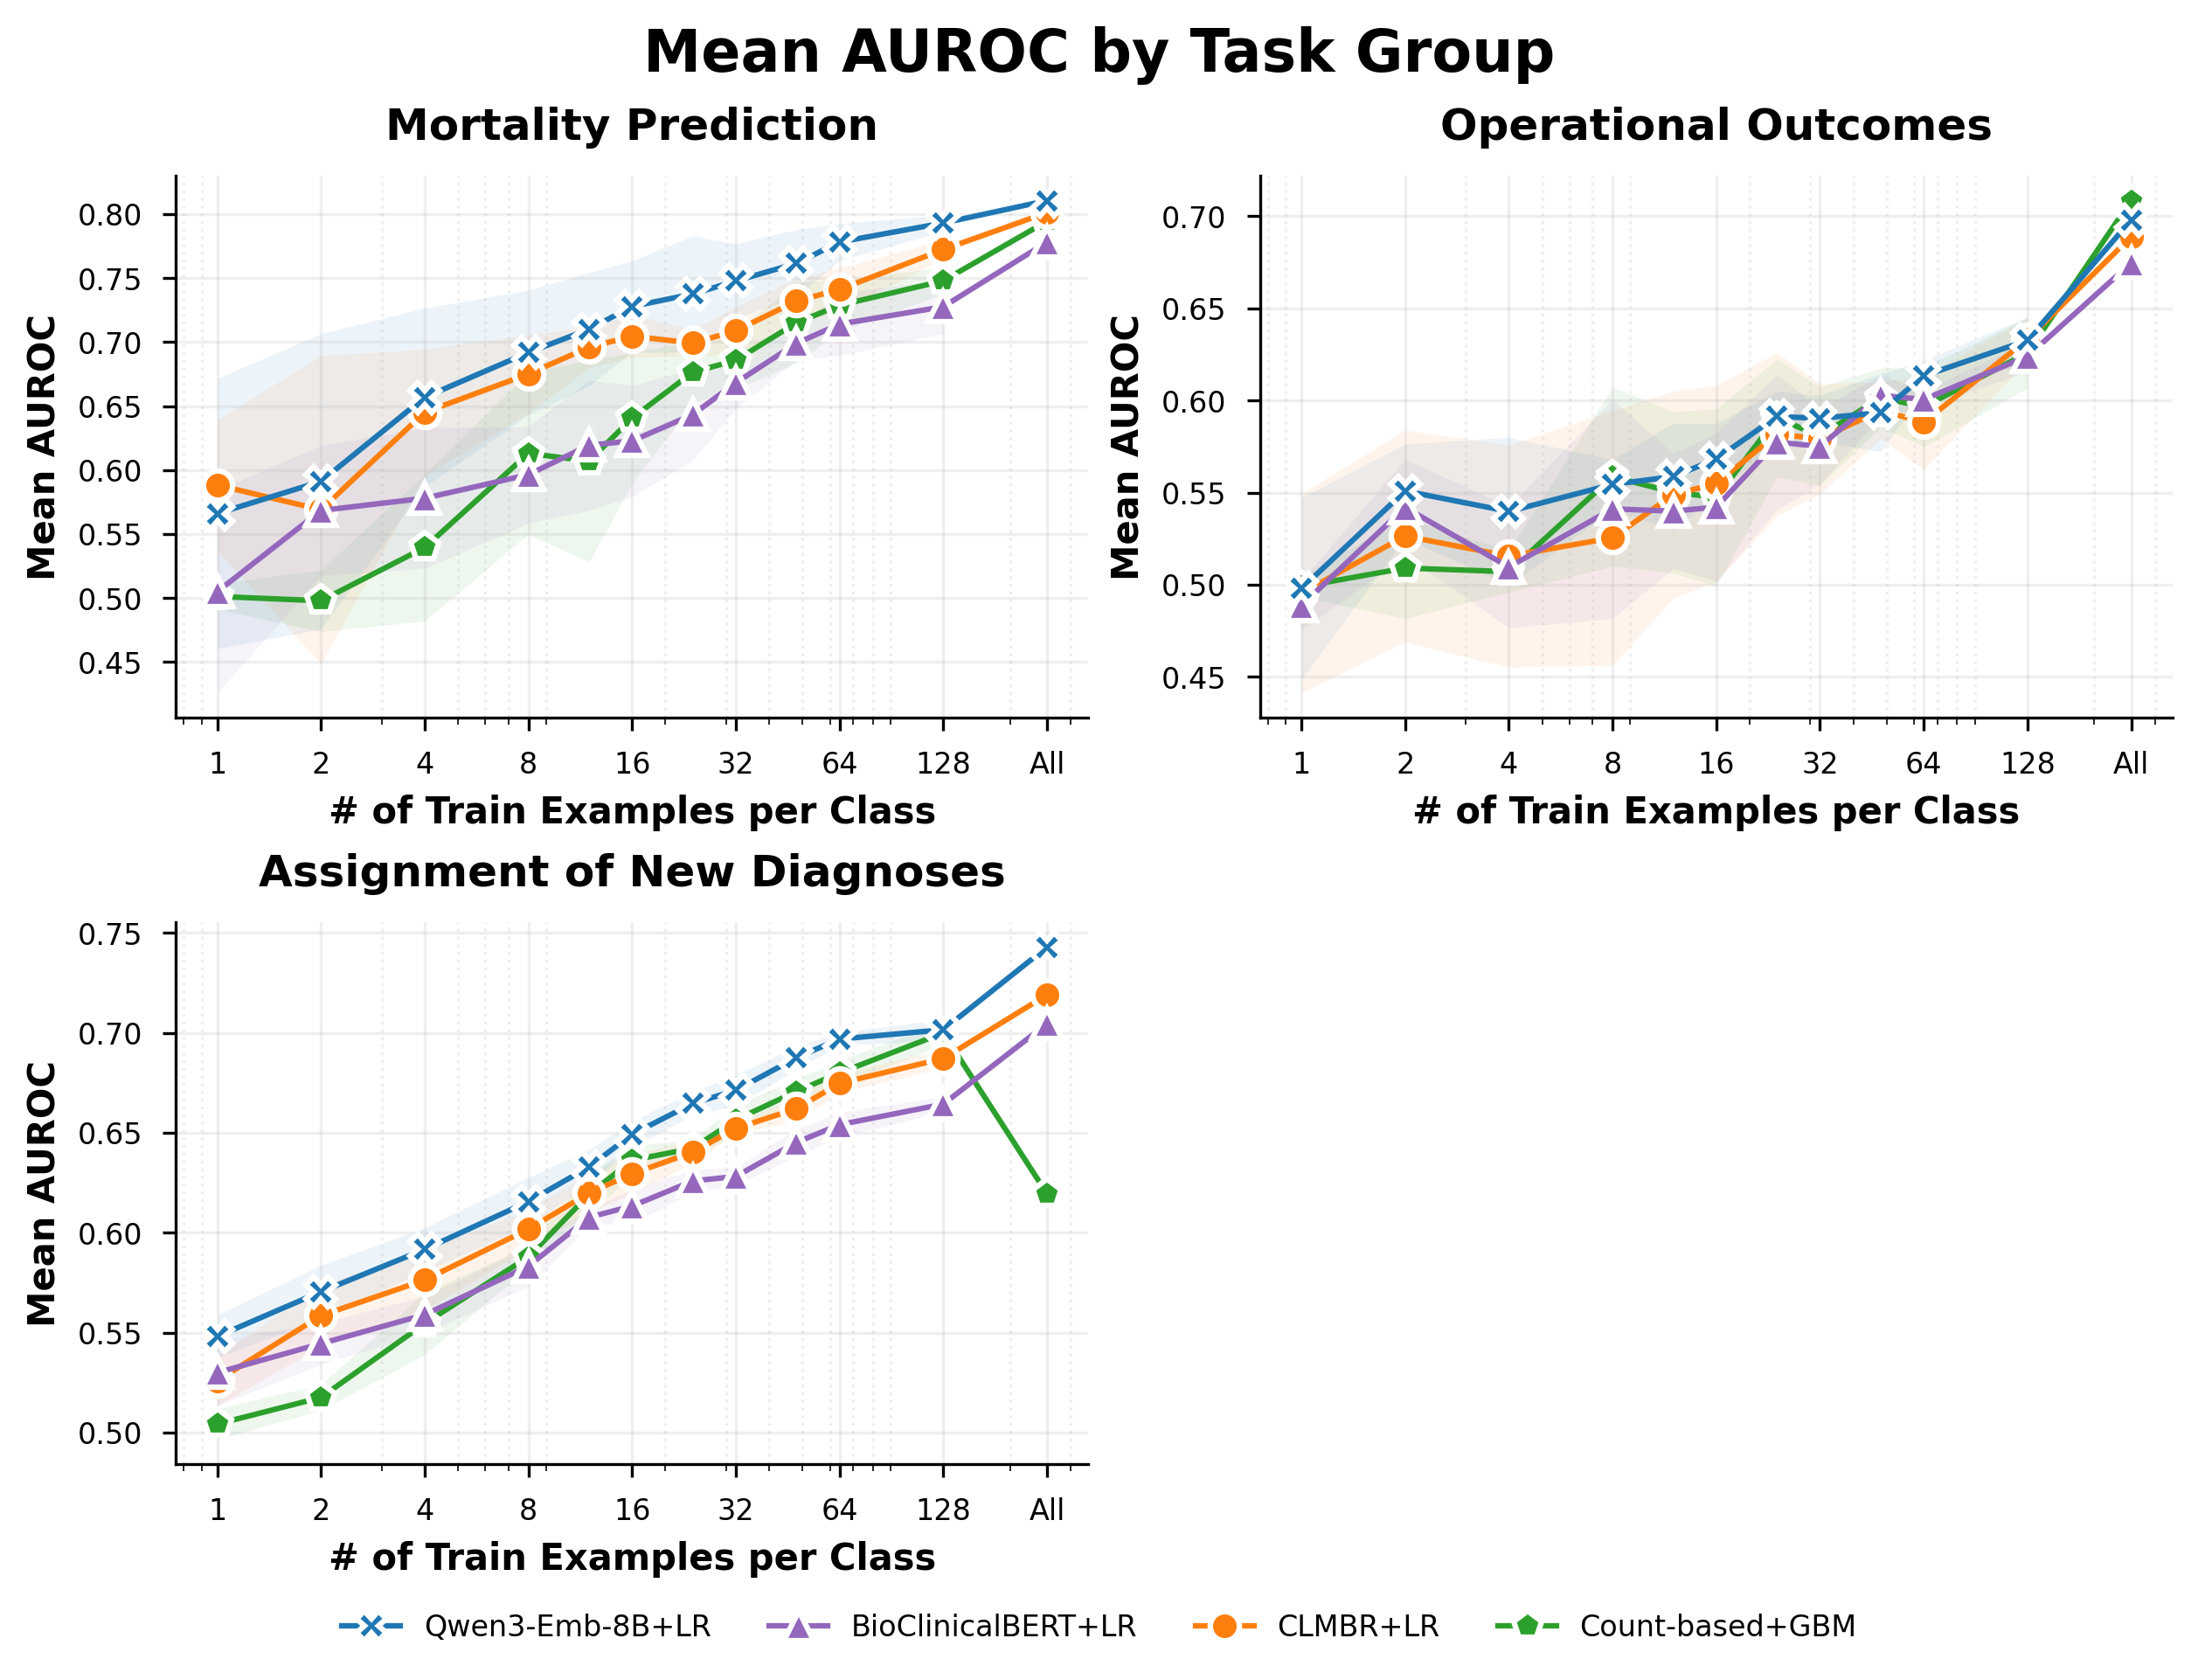

In [9]:
PATH_TO_OUTPUT_DIR = "./plots/"
os.makedirs(PATH_TO_OUTPUT_DIR, exist_ok=True)

MODEL_HEADS = None  
all_scores_filtered = all_scores[all_scores["model"].isin(["count", "clmbr", "qwen3", "bioclinicalbert"])]

# # Individual task plots
# plot_all_labeling_functions(
#     all_scores_filtered[all_scores_filtered["sub_task"] == "disease_onset"],
#     score=method,
#     path_to_output_dir=PATH_TO_OUTPUT_DIR,
#     model_heads=MODEL_HEADS,
#     is_x_scale_log=True,
#     is_std_bars=True
# )

# Task group aggregated plots
plot_all_task_groups(
    all_scores_filtered,
    score=method,
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=MODEL_HEADS,
    is_x_scale_log=True,
    shadedregion=True,
    addlinesdiagnoses=False
)

# # Boxplots
# plot_all_task_group_box_plots(
#     all_scores_filtered,
#     score=method,
#     path_to_output_dir=PATH_TO_OUTPUT_DIR,
#     model_heads=MODEL_HEADS
# )

# # Radar plot for specific k
# plot_radar_chart(
#     all_scores_filtered,
#     k=32,
#     path_to_output_dir=PATH_TO_OUTPUT_DIR,
#     score=method,
#     model_heads=MODEL_HEADS
# )

In [10]:
model_name = {
    "qwen": "GTE-Qwen2-7B+LR",
    "qwen3": "Qwen3-Emb-8B+LR",
    "llm2vec": "LLM2Vec-Llama-3.1 8B+LR",
    "clmbr": "CLMBR+LR",
    "count": "Count-based+GBM",
    "bioclinicalbert": "BioClinicalBERT+LR",
    "qwenclmbrcodes": "Sensitivity analysis"
}

model_palette = {
    "Qwen3-Emb-8B+LR": "#1f77b4",     # blue
    "CLMBR+LR": "#ff7f0e",                  # orange
    "Count-based+GBM": "#2ca02c",          # green
    "LLM2Vec-Llama-3.1 8B+LR": "#d62728",   # red
    "GTE-Qwen2-7B+LR": "#9467bd",           # purple
    "BioClinicalBERT+LR": "#8c564b",         # brown
    "Sensitivity analysis": "#e377c2"        # pink
}

model_markers = {
    "Qwen3-Emb-8B+LR": "X",
    "CLMBR+LR": "o",
    "Count-based+GBM": "p",
    #"LLM2Vec-Llama-3.1 8B+LR": "^", 
    #"GTE-Qwen2-7B+LR": "*",
    "BioClinicalBERT+LR": "^",
    "Qwen3-Emb-8B CLMBR codes+LR": "^",
    "Sensitivity analysis": "p"
}

task_mapping = {
    "disease_onset": "Assignment of New Diagnoses",
    "OMOP_9201": "Operational Outcomes",
    "OMOP_4306655": "Mortality Prediction",
}

selected_diseases = {"OMOP_4306655", "OMOP_9201"}

legend_order = ["Qwen3-Emb-8B+LR", "CLMBR+LR", "Count-based+GBM", "LLM2Vec-Llama-3.1 8B+LR", "GTE-Qwen2-7B+LR", "BioClinicalBERT+LR", "Sensitivity analysis"]


In [11]:
def create_table(subtasks, valuetable):
    # -------------------------------------------------
    # 1. Filter for AUROC and specific k
    # -------------------------------------------------
    k_value = -1   # choose 2 or 4
    if subtasks:
        relcol = "sub_task"
    else:
        relcol = "labeling_function"

    filtered_scores = (
        all_scores[
            (all_scores["score"] == "auroc") &
            (all_scores["k"] == k_value)
        ]
        .copy()
    )

    # Optional: rename models
    filtered_scores["model"] = filtered_scores["model"].map(model_name)

    # -------------------------------------------------
    # 2. Aggregate over replicates
    # -------------------------------------------------
    agg = (
        filtered_scores
        .groupby(["model", relcol])
        .agg(
            mean=("mean", "mean"),
            count=("mean", "count"),
            var_sum=("std", lambda x: np.sum(x**2)),
        )
        .reset_index()
    )

    # -------------------------------------------------
    # 3. Add std
    # -------------------------------------------------
    agg["std"] = np.sqrt(agg["var_sum"] / (agg["count"] ** 2))
    agg["lower"] = agg["mean"] - 1.96 * agg["std"]
    agg["upper"] = agg["mean"] + 1.96 * agg["std"]

    # -------------------------------------------------
    # 4. Create formatted string
    # -------------------------------------------------
    agg["auroc_formatted"] = agg.apply(
        lambda row: f"{row['mean']:.3f} ({row['lower']:.3f}–{row['upper']:.3f})",
        axis=1
    )

    # -------------------------------------------------
    # 5. Order models
    # -------------------------------------------------
    model_order = list(model_name.values())
    agg["model"] = pd.Categorical(
        agg["model"],
        categories=model_order,
        ordered=True
    )

    # -------------------------------------------------
    # 6. Pivot table (models x labeling_functions)
    # -------------------------------------------------
    pretty_table = agg.pivot(
        index="model",
        columns=relcol,
        values="auroc_formatted"
    )

    # -------------------------------------------------
    # 7. Mean across labeling_functions
    # -------------------------------------------------
    numerical_pivot = agg.pivot(
        index="model",
        columns=relcol,
        values="mean"
    )

        # get per-LF stds (NOT recomputed from means)
    std_pivot = agg.pivot(
        index="model",
        columns=relcol,
        values="std"
    )

    mean_across = numerical_pivot.mean(axis=1)
    n = numerical_pivot.shape[1]

    # sum variances like original code
    var_sum = (std_pivot**2).sum(axis=1)

    std_total = np.sqrt(var_sum / (n**2))

    lower = mean_across - 1.96 * std_total
    upper = mean_across + 1.96 * std_total

    mean_across = mean_across.round(3)
    lower = lower.round(3)
    upper = upper.round(3)

    mean_formatted = pd.DataFrame({
        f"Mean Across LFs (k={k_value})":
            [f"{m:.3f} ({l:.3f}–{u:.3f})"
            for m, l, u in zip(mean_across, lower, upper)]
    }, index=mean_across.index)

    pretty_table = pretty_table.join(mean_formatted)

    # Ensure correct order
    pretty_table = pretty_table.reindex(model_order)

    return pretty_table

all_scores_filtered_allmodels = all_scores[all_scores["model"].isin(["count", "clmbr", "qwen3", "bioclinicalbert", "llm2vec", "qwen", "qwenclmbrcodes"])]
pretty_table_subtasks = create_table(subtasks=True, valuetable=all_scores_filtered_allmodels)
pretty_table_subtasks

,OMOP_4306655,OMOP_9201,disease_onset,Mean Across LFs (k=-1)
model,,,,
GTE-Qwen2-7B+LR,0.804 (0.774–0.835),0.695 (0.691–0.699),0.747 (0.732–0.762),0.749 (0.737–0.760)
Qwen3-Emb-8B+LR,0.811 (0.781–0.840),0.698 (0.694–0.702),0.743 (0.731–0.755),0.751 (0.740–0.761)
LLM2Vec-Llama-3.1 8B+LR,0.796 (0.766–0.827),0.690 (0.686–0.694),0.731 (0.717–0.746),0.739 (0.728–0.751)
CLMBR+LR,0.801 (0.772–0.830),0.689 (0.685–0.693),0.719 (0.708–0.731),0.736 (0.726–0.747)
Count-based+GBM,0.795 (0.766–0.824),0.708 (0.705–0.712),0.619 (0.607–0.631),0.707 (0.697–0.718)
BioClinicalBERT+LR,0.778 (0.746–0.811),0.675 (0.671–0.678),0.705 (0.693–0.717),0.719 (0.708–0.731)
Sensitivity analysis,0.806 (0.775–0.836),0.687 (0.683–0.691),0.736 (0.723–0.749),0.743 (0.732–0.754)


In [12]:
pretty_table_subtasks.drop(["GTE-Qwen2-7B+LR", "LLM2Vec-Llama-3.1 8B+LR"])

,OMOP_4306655,OMOP_9201,disease_onset,Mean Across LFs (k=-1)
model,,,,
Qwen3-Emb-8B+LR,0.811 (0.781–0.840),0.698 (0.694–0.702),0.743 (0.731–0.755),0.751 (0.740–0.761)
CLMBR+LR,0.801 (0.772–0.830),0.689 (0.685–0.693),0.719 (0.708–0.731),0.736 (0.726–0.747)
Count-based+GBM,0.795 (0.766–0.824),0.708 (0.705–0.712),0.619 (0.607–0.631),0.707 (0.697–0.718)
BioClinicalBERT+LR,0.778 (0.746–0.811),0.675 (0.671–0.678),0.705 (0.693–0.717),0.719 (0.708–0.731)
Sensitivity analysis,0.806 (0.775–0.836),0.687 (0.683–0.691),0.736 (0.723–0.749),0.743 (0.732–0.754)


## Generate plot comparing EHRSHOT and UKB results

In [13]:
all_scores_filtered_sensitivity = all_scores[all_scores["model"].isin(["clmbr", "qwen3", "qwenclmbrcodes"])]

In [14]:
all_scores_filtered_sensitivity

,labeling_function,sub_task,model,head,replicate,k,score,value,std,lower,mean,upper
0,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auroc,0.750422,1.709814e-02,0.714059,0.750825,0.782013
1,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,brier,0.001965,1.281034e-04,0.001720,0.001963,0.002201
2,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auprc,0.014027,4.173521e-03,0.009079,0.015428,0.025512
3,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,auroc,0.487025,1.932095e-02,0.446997,0.485973,0.523639
4,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,brier,0.249992,3.043115e-08,0.249992,0.249992,0.249992
...,...,...,...,...,...,...,...,...,...,...,...,...
16795,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,brier,0.239028,4.722084e-05,0.238935,0.239027,0.239119
16796,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,auprc,0.025943,8.109062e-03,0.014317,0.027224,0.045255
16797,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,auroc,0.780661,1.507283e-02,0.751749,0.781156,0.811110
16798,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,brier,0.208084,2.774924e-04,0.207540,0.208072,0.208601


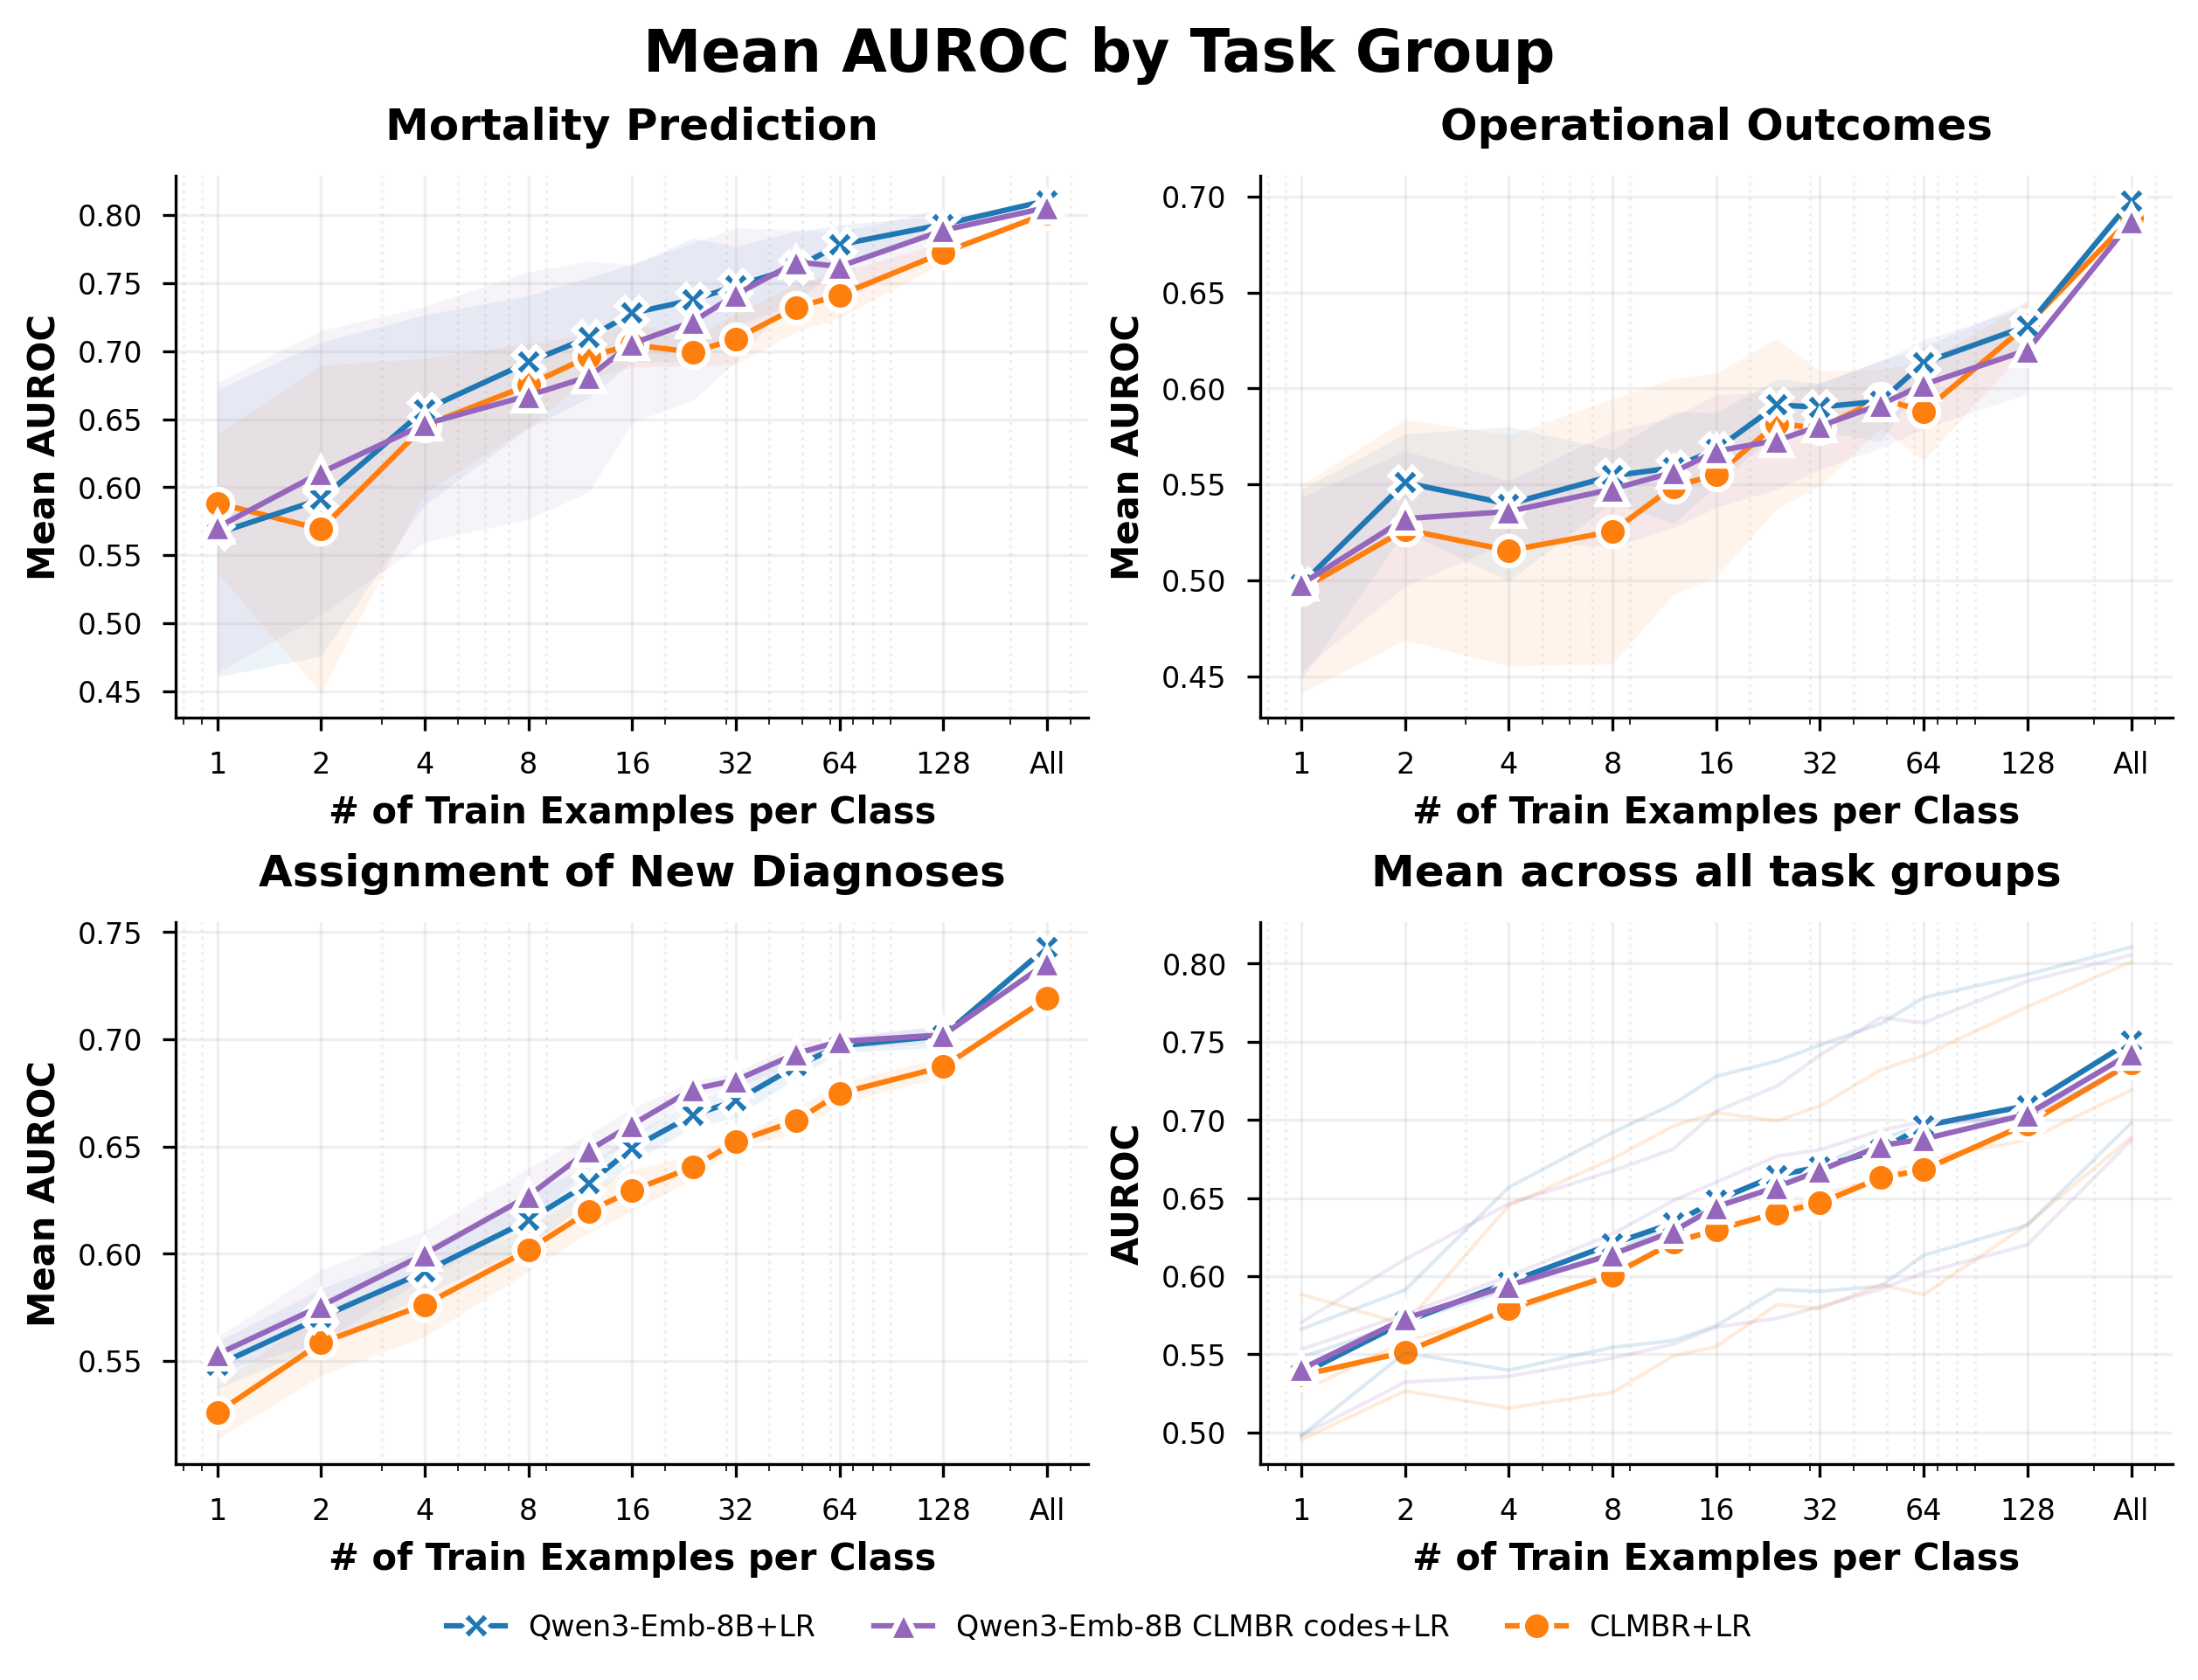

In [15]:
# Task group aggregated plots
plot_sensitivity_analysis( #plot_all_task_groups
    all_scores_filtered_sensitivity,
    score=method,
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=None,
    is_x_scale_log=True,
    shadedregion=True
)

In [16]:
all_scores_filtered_sensitivity

,labeling_function,sub_task,model,head,replicate,k,score,value,std,lower,mean,upper
0,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auroc,0.750422,1.709814e-02,0.714059,0.750825,0.782013
1,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,brier,0.001965,1.281034e-04,0.001720,0.001963,0.002201
2,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,-1,auprc,0.014027,4.173521e-03,0.009079,0.015428,0.025512
3,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,auroc,0.487025,1.932095e-02,0.446997,0.485973,0.523639
4,Pneumonia,disease_onset,clmbr,lr_lbfgs,0,1,brier,0.249992,3.043115e-08,0.249992,0.249992,0.249992
...,...,...,...,...,...,...,...,...,...,...,...,...
16795,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,brier,0.239028,4.722084e-05,0.238935,0.239027,0.239119
16796,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,3,128,auprc,0.025943,8.109062e-03,0.014317,0.027224,0.045255
16797,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,auroc,0.780661,1.507283e-02,0.751749,0.781156,0.811110
16798,death,OMOP_4306655,qwenclmbrcodes,lr_lbfgs,4,128,brier,0.208084,2.774924e-04,0.207540,0.208072,0.208601


In [17]:
import pandas as pd

cols_to_mean = ["value", "std", "lower", "mean", "upper"]

df_combined = (
    all_scores_filtered_sensitivity.groupby(
        ["sub_task", "model", "head", "replicate", "k", "score"],
        as_index=False
    )[cols_to_mean]
    .mean()
)
df_combined

,sub_task,model,head,replicate,k,score,value,std,lower,mean,upper
0,OMOP_4306655,clmbr,lr_lbfgs,0,-1,auprc,0.048549,0.013816,0.027229,0.050448,0.079687
1,OMOP_4306655,clmbr,lr_lbfgs,0,-1,auroc,0.801212,0.014652,0.773155,0.801126,0.828669
2,OMOP_4306655,clmbr,lr_lbfgs,0,-1,brier,0.002070,0.000129,0.001831,0.002068,0.002332
3,OMOP_4306655,clmbr,lr_lbfgs,0,1,auprc,0.003719,0.000427,0.003059,0.003804,0.004729
4,OMOP_4306655,clmbr,lr_lbfgs,0,1,auroc,0.637234,0.018160,0.603073,0.637790,0.673687
...,...,...,...,...,...,...,...,...,...,...,...
1507,disease_onset,qwenclmbrcodes,lr_lbfgs,4,64,auroc,0.701738,0.020120,0.661533,0.701432,0.739328
1508,disease_onset,qwenclmbrcodes,lr_lbfgs,4,64,brier,0.258907,0.000288,0.258350,0.258904,0.259470
1509,disease_onset,qwenclmbrcodes,lr_lbfgs,4,128,auprc,0.011488,0.001676,0.009363,0.011967,0.015865
1510,disease_onset,qwenclmbrcodes,lr_lbfgs,4,128,auroc,0.700638,0.017035,0.666824,0.700454,0.733253


## Generate plot showing sensitivity analysis (Clmbr vs ukb clmbr subset using qwen3)

In [18]:
## Read in data from EHRShot task groups
chexpert_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{method}/chexpert_pretty.csv")
lab_values_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{method}/lab_values_pretty.csv")
new_diagnoses_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{method}/new_diagnoses_pretty.csv")
operational_outcomes_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{method}/operational_outcomes_pretty.csv")
operational_outcomes_df

,model,head,All,1,2,4,8,12,16,24,32,48,64,128
0,clmbr,lr_lbfgs,0.824,0.555,0.590,0.628,0.659,0.688,0.713,0.724,0.739,0.758,0.768,0.789
1,count,gbm,0.824,0.509,0.530,0.533,0.594,0.592,0.622,0.663,0.683,0.707,0.718,0.768
2,llm,lr_lbfgs,0.797,0.543,0.587,0.633,0.658,0.685,0.687,0.707,0.717,0.734,0.742,0.761
3,llm-bert,lr_lbfgs,0.738,0.520,0.550,0.597,0.606,0.612,0.625,0.644,0.660,0.668,0.675,0.708


In [19]:
all_dfs_ehrshot = pd.DataFrame()
for df, subtask in [(chexpert_df, "chexpert"), (lab_values_df, "lab_values"), (operational_outcomes_df, "operational_outcomes"), (new_diagnoses_df, "new_diagnoses")]:
    score = method
    df_long = (
        df.melt(
            id_vars=["model", "head"],
            var_name="k",
            value_name="value"
        )
    )

    # convert "All" -> -1 and cast to int
    df_long["k"] = df_long["k"].replace({"All": -1}).astype(int)
    df_long["sub_task"] = subtask
    df_long["score"] = method
    df_long["labeling_function"] = "EHRSHOT"
    all_dfs_ehrshot = pd.concat([all_dfs_ehrshot, df_long], ignore_index=True)

all_dfs_ehrshot = all_dfs_ehrshot[["sub_task", "model", "head", "k", "score", "value", "labeling_function"]]
# rename model llm-bert to bioclinicalbert and llm to qwen3
all_dfs_ehrshot["model"] = all_dfs_ehrshot["model"].replace({"llm-bert": "bioclinicalbert", "llm": "qwen3"})
all_dfs_ehrshot

,sub_task,model,head,k,score,value,labeling_function
0,chexpert,clmbr,lr_lbfgs,-1,auroc,0.713,EHRSHOT
1,chexpert,count,gbm,-1,auroc,0.686,EHRSHOT
2,chexpert,qwen3,lr_lbfgs,-1,auroc,0.722,EHRSHOT
3,chexpert,bioclinicalbert,lr_lbfgs,-1,auroc,0.679,EHRSHOT
4,chexpert,clmbr,lr_lbfgs,1,auroc,0.525,EHRSHOT
...,...,...,...,...,...,...,...
187,new_diagnoses,bioclinicalbert,lr_lbfgs,64,auroc,0.657,EHRSHOT
188,new_diagnoses,clmbr,lr_lbfgs,128,auroc,0.712,EHRSHOT
189,new_diagnoses,count,gbm,128,auroc,0.728,EHRSHOT
190,new_diagnoses,qwen3,lr_lbfgs,128,auroc,0.719,EHRSHOT


In [20]:
# get all relevant data from UKB and combine disease_onset values
task_groups = ['Mortality Prediction', 'Operational Outcomes', 'Assignment of New Diagnoses']
combined_dfs = pd.DataFrame()
for task in task_groups:
    df_filtered = filter_df(all_scores, score=score, task_group=task, model_heads=None)
    combined_dfs = pd.concat([combined_dfs, df_filtered], axis=0)

cols_to_mean = ["value", "std", "lower", "mean", "upper"]
df_combined = (
    combined_dfs.groupby(
        ["sub_task", "model", "head", "replicate", "k", "score"],
        as_index=False
    )[cols_to_mean]
    .mean()
)
df_combined["labeling_function"] = df_combined["sub_task"]
all_dfs_ukb = df_combined[["sub_task", "model", "head", "k", "score", "value"]]
all_dfs_ukb["labeling_function"] = "UKB"
all_dfs_ukb = all_dfs_ukb[all_dfs_ukb["model"] != "qwenclmbrcodes"]
all_dfs_ukb.head()

/tmp/ipykernel_2164809/1151065545.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_dfs_ukb["labeling_function"] = "UKB"


,sub_task,model,head,k,score,value,labeling_function
0,OMOP_4306655,bioclinicalbert,lr_lbfgs,-1,auroc,0.778161,UKB
1,OMOP_4306655,bioclinicalbert,lr_lbfgs,1,auroc,0.631515,UKB
2,OMOP_4306655,bioclinicalbert,lr_lbfgs,2,auroc,0.648244,UKB
3,OMOP_4306655,bioclinicalbert,lr_lbfgs,4,auroc,0.652331,UKB
4,OMOP_4306655,bioclinicalbert,lr_lbfgs,8,auroc,0.597645,UKB


In [21]:
## combine the two dataframes and create plots with new function
all_dfs_combined = pd.concat([all_dfs_ukb, all_dfs_ehrshot], ignore_index=True)

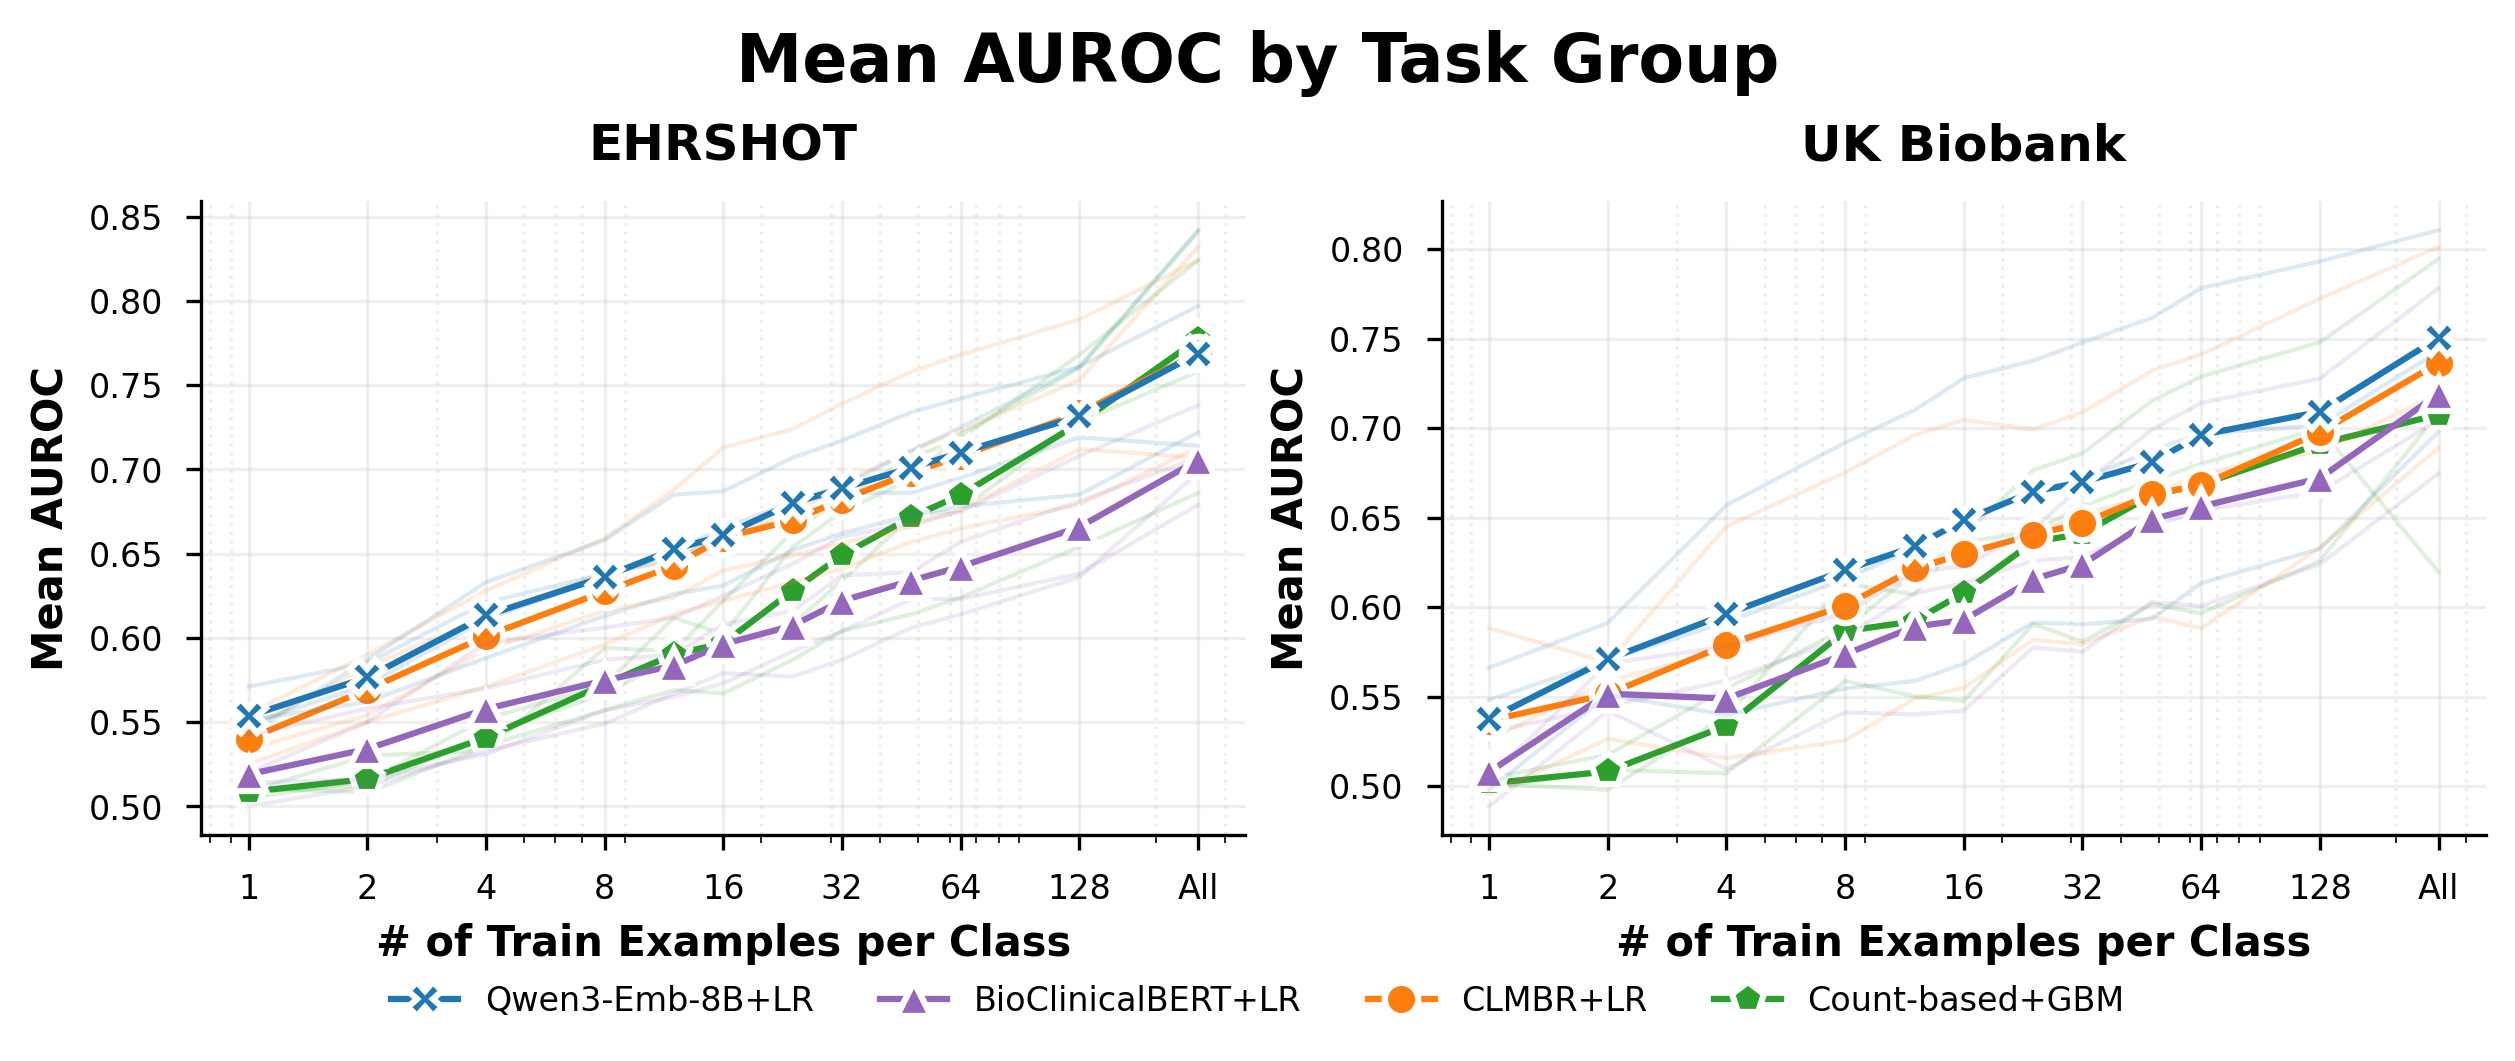

In [23]:
# Task group aggregated plots
plot_comparison( #plot_all_task_groups
    all_dfs_combined[~all_dfs_combined["model"].isin(["qwen", "llm2vec"])],
    score=method,
    path_to_output_dir=PATH_TO_OUTPUT_DIR,
    model_heads=None,
    is_x_scale_log=True,
    shadedregion=False
)